# Random Forest Workload Detection - Results Visualization

This notebook/script visualizes results from the unified pipeline.

To generate results, first run:
    python run_pipeline.py

Sections:
  1. Setup & Data Loading
  2. Normalization Comparison
  3. Feature Type Comparison (Linear vs RQA vs Combined)
  4. Performance Metrics
  5. Baseline Impact
  6. Learning Curves
  7. Summary Tables

## Setup/Imports

In [1]:
import os
import json
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configuration
OUTPUT_DIR = Path("model_output")
FIG_DIR = Path("figs")
FIG_DIR.mkdir(exist_ok=True)

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("colorblind")


# %% Helper Functions

def load_results(json_filename):
    """Load results from JSON file."""
    json_path = OUTPUT_DIR / json_filename
    if not json_path.exists():
        print(f"⚠️  File not found: {json_filename}")
        return None
    
    with open(json_path, "r") as f:
        return json.load(f)


def extract_metrics(results, metric_prefix="test_bal_acc"):
    """Extract mean and std for a metric from results."""
    if results is None:
        return np.nan, np.nan
    
    metrics = results.get("metrics", {})
    mean = metrics.get(f"{metric_prefix}_mean", 0) * 100.0
    std = metrics.get(f"{metric_prefix}_std", 0) * 100.0
    
    return mean, std


def format_metric(mean, std):
    """Format metric as 'mean ± std'."""
    if np.isnan(mean):
        return "N/A"
    if std == 0:
        return f"{mean:.1f}%"
    return f"{mean:.1f}% ± {std:.1f}%"


def plot_confusion_matrix(results, title, output_path, labels=None):
    """Plot confusion matrix from results."""
    if results is None:
        print(f"⚠️  Cannot plot: {title}")
        return
    
    if labels is None:
        labels = ["L", "M", "H"]
    
    cm = np.array(results["confusion_matrix"])
    
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt=".1f",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        cbar_kws={"label": "Percentage (%)"},
        ax=ax
    )
    
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, format="svg")
    plt.close()
    
    print(f"✓ Saved: {output_path}")


# %% Check Pipeline Status

def check_pipeline_status():
    """Check which experiments have been completed."""
    if not OUTPUT_DIR.exists():
        print("⚠️  Output directory not found. Please run the pipeline first:")
        print("   python run_pipeline.py")
        return False
    
    json_files = list(OUTPUT_DIR.glob("*.json"))
    
    if not json_files:
        print("⚠️  No results found. Please run the pipeline first:")
        print("   python run_pipeline.py")
        return False
    
    print(f"✓ Found {len(json_files)} result files")
    return True


if not check_pipeline_status():
    print("\nExiting. Run pipeline first.")
    exit()


✓ Found 12 result files


## 2. Compare Normalization Types

In [ ]:
print("\n" + "="*80)
print("NORMALIZATION COMPARISON")
print("="*80)

norm_dir = FIG_DIR / "normalization"
norm_dir.mkdir(exist_ok=True)

# Define normalization experiments
normalization_experiments = {
    "None": {
        "random": "linear_pose_none_random.json",
        "participant": "linear_pose_none_participant.json"
    },
    "MinMax": {
        "random": "linear_pose_minmax_random.json",
        "participant": "linear_pose_minmax_participant.json"
    },
    "Z-Score": {
        "random": "linear_pose_zscore_random.json",
        "participant": "linear_pose_zscore_participant.json"
    }
}

# Collect results
norm_methods = list(normalization_experiments.keys())
random_means, random_stds = [], []
participant_means, participant_stds = [], []

for method in norm_methods:
    # Random split
    rand_results = load_results(normalization_experiments[method]["random"])
    rand_mean, rand_std = extract_metrics(rand_results)
    random_means.append(rand_mean)
    random_stds.append(rand_std)
    
    # Participant split
    part_results = load_results(normalization_experiments[method]["participant"])
    part_mean, part_std = extract_metrics(part_results)
    participant_means.append(part_mean)
    participant_stds.append(part_std)

# Plot comparison
x = np.arange(len(norm_methods))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

bars1 = ax.bar(
    x - width/2, random_means, width,
    label='Cross-Task (Random)',
    yerr=random_stds, capsize=4,
    color='steelblue', edgecolor='black', linewidth=1.2
)

bars2 = ax.bar(
    x + width/2, participant_means, width,
    label='Cross-Participant',
    yerr=participant_stds, capsize=4,
    color='coral', edgecolor='black', linewidth=1.2
)

# Annotate bars
for bars, means in [(bars1, random_means), (bars2, participant_means)]:
    for bar, mean in zip(bars, means):
        if not np.isnan(mean):
            ax.text(
                bar.get_x() + bar.get_width()/2,
                bar.get_height() + 1,
                f"{mean:.1f}%",
                ha='center', va='bottom', fontsize=9
            )

ax.set_ylabel('Balanced Accuracy (%)')
ax.set_xlabel('Normalization Method')
ax.set_title('Effect of Normalization on Linear Pose Features')
ax.set_xticks(x)
ax.set_xticklabels(norm_methods)
ax.set_ylim(0, 100)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
output_path = norm_dir / "normalization_comparison.svg"
plt.savefig(output_path, dpi=300)
plt.show()
print(f"✓ Saved: {output_path}")

# Print table
print("\nNormalization Results:")
print(f"{'Method':<15} {'Random':<25} {'Participant':<25}")
print("-" * 65)
for method, rm, rs, pm, ps in zip(norm_methods, random_means, random_stds, 
                                     participant_means, participant_stds):
    print(f"{method:<15} {format_metric(rm, rs):<25} {format_metric(pm, ps):<25}")

## 3. Feature Type Comparisons


FEATURE TYPE COMPARISON
⚠️  File not found: linear_pose_exp_random.json
⚠️  File not found: linear_pose_exp_participant.json
⚠️  File not found: rqa_pose_exp_random.json
⚠️  File not found: rqa_pose_exp_participant.json
⚠️  File not found: linear_rqa_exp_random.json
⚠️  File not found: linear_rqa_exp_participant.json


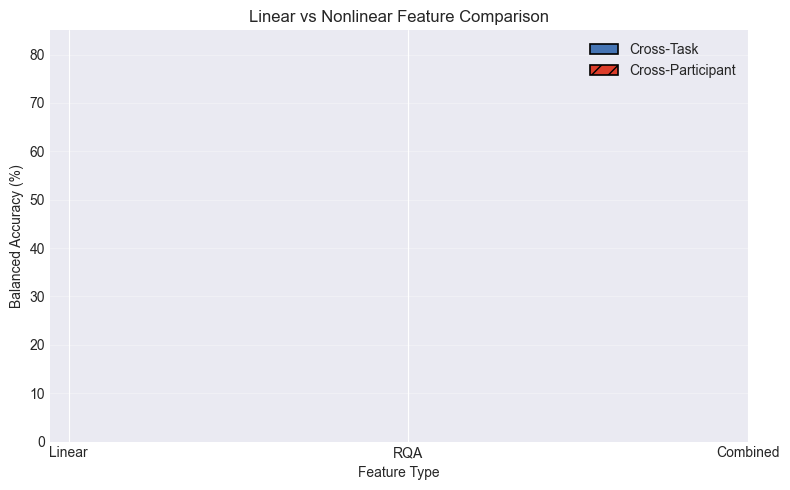

✓ Saved: figs/features/feature_type_comparison.svg
⚠️  File not found: linear_pose_exp_random.json
⚠️  Cannot plot: Linear Features - Random
⚠️  File not found: linear_pose_exp_participant.json
⚠️  Cannot plot: Linear Features - Participant
⚠️  File not found: rqa_pose_exp_random.json
⚠️  Cannot plot: RQA Features - Random
⚠️  File not found: rqa_pose_exp_participant.json
⚠️  Cannot plot: RQA Features - Participant
⚠️  File not found: linear_rqa_exp_random.json
⚠️  Cannot plot: Combined Features - Random
⚠️  File not found: linear_rqa_exp_participant.json
⚠️  Cannot plot: Combined Features - Participant


In [5]:
print("\n" + "="*80)
print("FEATURE TYPE COMPARISON")
print("="*80)

feature_dir = FIG_DIR / "features"
feature_dir.mkdir(exist_ok=True)

# Define feature type experiments (using best normalization - zscore)
feature_experiments = {
    "Linear": {
        "random": "linear_pose_exp_random.json",
        "participant": "linear_pose_exp_participant.json"
    },
    "RQA": {
        "random": "rqa_pose_exp_random.json",
        "participant": "rqa_pose_exp_participant.json"
    },
    "Combined": {
        "random": "linear_rqa_exp_random.json",
        "participant": "linear_rqa_exp_participant.json"
    }
}

# Collect results
feature_types = list(feature_experiments.keys())
ct_means, ct_stds = [], []
cp_means, cp_stds = [], []

for ftype in feature_types:
    # Cross-task
    ct_results = load_results(feature_experiments[ftype]["random"])
    ct_mean, ct_std = extract_metrics(ct_results)
    ct_means.append(ct_mean)
    ct_stds.append(ct_std)
    
    # Cross-participant
    cp_results = load_results(feature_experiments[ftype]["participant"])
    cp_mean, cp_std = extract_metrics(cp_results)
    cp_means.append(cp_mean)
    cp_stds.append(cp_std)

# Plot comparison
x = np.arange(len(feature_types))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

bars1 = ax.bar(
    x - width/2, ct_means, width,
    label='Cross-Task',
    yerr=ct_stds, capsize=4,
    color='#4574b3', edgecolor='black', linewidth=1.2
)

bars2 = ax.bar(
    x + width/2, cp_means, width,
    label='Cross-Participant',
    yerr=cp_stds, capsize=4,
    color='#dc3d2a', edgecolor='black', linewidth=1.2,
    hatch='//'
)

# Annotate
for bars, means in [(bars1, ct_means), (bars2, cp_means)]:
    for bar, mean in zip(bars, means):
        if not np.isnan(mean):
            ax.text(
                bar.get_x() + bar.get_width()/2,
                bar.get_height() + 1,
                f"{mean:.1f}%",
                ha='center', va='bottom', fontsize=9
            )

ax.set_ylabel('Balanced Accuracy (%)')
ax.set_xlabel('Feature Type')
ax.set_title('Linear vs Nonlinear Feature Comparison')
ax.set_xticks(x)
ax.set_xticklabels(feature_types)
ax.set_ylim(0, 85)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
output_path = feature_dir / "feature_type_comparison.svg"
plt.savefig(output_path, dpi=300)
plt.show()
print(f"✓ Saved: {output_path}")

# Confusion matrices for each feature type
cm_dir = feature_dir / "confusion_matrices"
cm_dir.mkdir(exist_ok=True)

for ftype in feature_types:
    for split in ["random", "participant"]:
        results = load_results(feature_experiments[ftype][split])
        title = f"{ftype} Features - {split.capitalize()}"
        output_name = f"cm_{ftype.lower()}_{split}.svg"
        plot_confusion_matrix(results, title, cm_dir / output_name)

## 4. Performance Metrics

In [ ]:
print("\n" + "="*80)
print("PERFORMANCE METRICS")
print("="*80)

perf_dir = FIG_DIR / "performance"
perf_dir.mkdir(exist_ok=True)

# Load performance metric results
perf_random = load_results("performance_exp_random.json")
perf_participant = load_results("performance_exp_participant.json")

# Extract metrics
perf_rand_mean, perf_rand_std = extract_metrics(perf_random)
perf_part_mean, perf_part_std = extract_metrics(perf_participant)

print(f"Performance Metrics Only:")
print(f"  Cross-Task:        {format_metric(perf_rand_mean, perf_rand_std)}")
print(f"  Cross-Participant: {format_metric(perf_part_mean, perf_part_std)}")

# Plot confusion matrices for performance
plot_confusion_matrix(
    perf_random, 
    "Performance Metrics - Cross-Task",
    perf_dir / "cm_performance_random.svg"
)
plot_confusion_matrix(
    perf_participant,
    "Performance Metrics - Cross-Participant", 
    perf_dir / "cm_performance_participant.svg"
)

## 5. Baseline Impact

In [ ]:
# %% ============================================================================
# 5. BASELINE IMPACT
# ============================================================================

print("\n" + "="*80)
print("BASELINE DATA IMPACT")
print("="*80)

baseline_dir = FIG_DIR / "baseline"
baseline_dir.mkdir(exist_ok=True)

# Define baseline experiments
baseline_experiments = {
    "Exp Only": "linear_pose_exp_participant.json",
    "+Bsl Pose": "linear_exp_bsl_pose.json",
    "+Bsl Perf": "linear_exp_bsl_perf.json",
}

# Collect results
conditions = []
accs = []

for condition, json_file in baseline_experiments.items():
    results = load_results(json_file)
    if results is not None:
        mean, std = extract_metrics(results)
        conditions.append(condition)
        accs.append(mean)
        print(f"{condition:<15}: {format_metric(mean, std)}")
    else:
        print(f"{condition:<15}: Not available (disabled in config)")

# Plot if we have baseline results
if len(conditions) > 1:
    plt.figure(figsize=(8, 5))
    plt.plot(conditions, accs, marker='o', color='firebrick', linewidth=2, markersize=8)
    
    # Annotate points
    for i, (cond, acc) in enumerate(zip(conditions, accs)):
        plt.text(i, acc + 1, f"{acc:.1f}%", ha='center', va='bottom', fontsize=10)
    
    plt.ylabel("Balanced Accuracy (%)")
    plt.xlabel("Feature Configuration")
    plt.title("Effect of Adding Baseline Data")
    plt.ylim(0, 100)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    
    output_path = baseline_dir / "baseline_impact.svg"
    plt.savefig(output_path, dpi=300)
    plt.show()
    print(f"✓ Saved: {output_path}")
else:
    print("\n⚠️  Baseline experiments not run. Enable in config to visualize.")

## 6. Learning Curves

In [8]:
import json
import numpy as np
import matplotlib.pyplot as plt

print("\n" + "="*80)
print("LEARNING CURVES")
print("="*80)

lc_dir = FIG_DIR / "learning_curves"
lc_dir.mkdir(parents=True, exist_ok=True)

def plot_learning_curve_from_path(json_path, title, output_path):
    """Plot learning curve from an absolute Path to the results JSON."""
    json_path = Path(json_path)
    if not json_path.exists():
        print(f"⚠️  File not found: {json_path}")
        return

    with open(json_path, "r") as f:
        results = json.load(f)

    minutes = results.get("minutes", [])
    lc_results = results.get("results", {})

    xs, means, ses = [], [], []
    for m in minutes:
        vals = lc_results.get(str(m), {}).get("BalancedAcc", [])
        if not vals:
            continue
        vals = np.asarray(vals, dtype=float)
        mu = vals.mean() * 100.0
        sd = vals.std(ddof=1) * 100.0 if vals.size > 1 else 0.0
        se = (sd / np.sqrt(vals.size)) if vals.size > 1 else 0.0

        xs.append(m); means.append(mu); ses.append(se)

    if not xs:
        print(f"⚠️  No valid points in {json_path.name}")
        return

    order = np.argsort(xs)
    xs    = np.asarray(xs)[order]
    means = np.asarray(means)[order]
    ses   = np.asarray(ses)[order]

    fig, ax = plt.subplots(figsize=(10, 6))

    # 95% CI band
    ci = 1.96 * ses
    ax.fill_between(xs, means - ci, means + ci, alpha=0.15, linewidth=0)

    # Mean line + markers
    ax.plot(xs, means, marker="o", linewidth=2, markersize=7,
            label="Balanced Accuracy (mean ± 95% CI)")

    # Labels above points
    for x, y in zip(xs, means):
        ax.text(x, y + 1.2, f"{y:.1f}%", ha="center", va="bottom", fontsize=9)

    ax.set_xlabel("Minutes of Experimental Data Added to Training", fontsize=11)
    ax.set_ylabel("Balanced Accuracy (%)", fontsize=11)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xticks(xs)

    ymin = max(0, np.floor((means.min() - 5) / 5) * 5)
    ymax = min(100, np.ceil((means.max() + 5) / 5) * 5)
    if ymin == ymax:
        ymin, ymax = max(0, means.min() - 5), min(100, means.max() + 5)
    ax.set_ylim(ymin, ymax)

    ax.grid(True, alpha=0.3)
    ax.legend(loc="lower right", frameon=False)

    plt.tight_layout()
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(output_path, dpi=300, format="svg")
    plt.close(fig)
    print(f"✓ Saved: {output_path}")

# Match the names your runner writes: OUTPUT_DIR / f"{name}.json"
learning_curve_specs = [
    ("lc_linear_perf_with_baseline",  "Learning Curves — Linear Pose + Performance (With Baseline)",  "lc_linear_perf_with_baseline.svg"),
    ("lc_linear_perf_no_baseline",    "Learning Curves — Linear Pose + Performance (No Baseline)",    "lc_linear_perf_no_baseline.svg"),
    ("lc_linear_only_with_baseline",  "Learning Curves — Linear Pose Only (With Baseline)",           "lc_linear_only_with_baseline.svg"),
    ("lc_linear_only_wo_baseline",    "Learning Curves — Linear Pose Only (No Baseline)",             "lc_linear_only_wo_baseline.svg"),
]

found_any = False
for name, title, outfile in learning_curve_specs:
    json_path = OUTPUT_DIR / f"{name}.json"  # <- use absolute path directly
    if json_path.exists():
        plot_learning_curve_from_path(json_path, title, lc_dir / outfile)
        found_any = True
    else:
        print(f"⚠️  File not found: {json_path}")

if not found_any:
    print("\n⚠️  No learning curves found.")
    print("   Check that your LC runs finished and wrote JSONs to:", OUTPUT_DIR.resolve())



LEARNING CURVES
✓ Saved: figs/learning_curves/lc_linear_perf_with_baseline.svg
✓ Saved: figs/learning_curves/lc_linear_perf_no_baseline.svg
✓ Saved: figs/learning_curves/lc_linear_only_with_baseline.svg
✓ Saved: figs/learning_curves/lc_linear_only_wo_baseline.svg


## 7. Summary Tables

In [9]:
print("\n" + "="*80)
print("COMPREHENSIVE SUMMARY")
print("="*80)

# Load experiment log
log_path = OUTPUT_DIR / "experiment_log.csv"

if log_path.exists():
    log_df = pd.read_csv(log_path)
    
    # Format for display
    print("\nAll Experiments:")
    print(f"{'Experiment':<40} {'Split':<15} {'Bal Acc':<25} {'F1':<25}")
    print("-" * 105)
    
    for _, row in log_df.iterrows():
        bal_acc = format_metric(
            row['test_bal_acc_mean'] * 100,
            row['test_bal_acc_std'] * 100
        )
        f1 = format_metric(
            row['test_f1_mean'] * 100,
            row['test_f1_std'] * 100
        )
        
        print(f"{row['experiment_name']:<40} {row['split_strategy']:<15} "
              f"{bal_acc:<25} {f1:<25}")
    
    print("=" * 105)
    
    # Export detailed summary
    summary_output = OUTPUT_DIR / "summary_table.csv"
    log_df.to_csv(summary_output, index=False)
    print(f"\n✓ Detailed summary saved to: {summary_output}")
    
    # Create LaTeX table for normalization comparison
    print("\n" + "="*80)
    print("LATEX TABLE: Normalization Comparison")
    print("="*80)
    
    print("\\begin{table}[h]")
    print("\\centering")
    print("\\caption{Effect of Normalization Methods on Classification Performance}")
    print("\\begin{tabular}{lcc}")
    print("\\hline")
    print("Normalization & Cross-Task & Cross-Participant \\\\")
    print("\\hline")
    
    for method in norm_methods:
        rand_results = load_results(normalization_experiments[method]["random"])
        part_results = load_results(normalization_experiments[method]["participant"])
        
        rand_mean, rand_std = extract_metrics(rand_results)
        part_mean, part_std = extract_metrics(part_results)
        
        print(f"{method} & {format_metric(rand_mean, rand_std)} & "
              f"{format_metric(part_mean, part_std)} \\\\")
    
    print("\\hline")
    print("\\end{tabular}")
    print("\\label{tab:normalization}")
    print("\\end{table}")
    
    # Create LaTeX table for feature comparison
    print("\n" + "="*80)
    print("LATEX TABLE: Feature Type Comparison")
    print("="*80)
    
    print("\\begin{table}[h]")
    print("\\centering")
    print("\\caption{Comparison of Linear, Nonlinear, and Combined Features}")
    print("\\begin{tabular}{lcc}")
    print("\\hline")
    print("Feature Type & Cross-Task & Cross-Participant \\\\")
    print("\\hline")
    
    for ftype in feature_types:
        ct_results = load_results(feature_experiments[ftype]["random"])
        cp_results = load_results(feature_experiments[ftype]["participant"])
        
        ct_mean, ct_std = extract_metrics(ct_results)
        cp_mean, cp_std = extract_metrics(cp_results)
        
        print(f"{ftype} & {format_metric(ct_mean, ct_std)} & "
              f"{format_metric(cp_mean, cp_std)} \\\\")
    
    print("\\hline")
    print("\\end{tabular}")
    print("\\label{tab:features}")
    print("\\end{table}")

else:
    print("\n⚠️  No experiment log found. Run pipeline first.")


# %% ============================================================================
# FINAL SUMMARY
# ============================================================================

print("\n" + "="*80)
print("✓ VISUALIZATION COMPLETE")
print("="*80)
print(f"\nAll figures saved to: {FIG_DIR}")
print("\nGenerated visualizations:")
print(f"  - Normalization comparison: {norm_dir}")
print(f"  - Feature type comparison: {feature_dir}")
print(f"  - Performance metrics: {perf_dir}")
if (baseline_dir / "baseline_impact.svg").exists():
    print(f"  - Baseline impact: {baseline_dir}")
if curves_found:
    print(f"  - Learning curves: {lc_dir}")

print("\n" + "="*80)


COMPREHENSIVE SUMMARY

All Experiments:
Experiment                               Split           Bal Acc                   F1                       
---------------------------------------------------------------------------------------------------------
linear_pose_none_random                  random          69.8% ± 1.6%              69.7% ± 1.6%             
linear_pose_minmax_random                random          79.6% ± 1.9%              79.6% ± 1.9%             
linear_pose_zscore_random                random          85.6% ± 1.2%              85.6% ± 1.2%             
linear_pose_none_participant             participant     43.9% ± 2.7%              42.9% ± 2.9%             
linear_pose_minmax_participant           participant     39.8% ± 2.7%              39.1% ± 2.7%             
linear_pose_zscore_participant           participant     47.2% ± 3.9%              46.4% ± 3.7%             
performance_exp_random                   random          55.0% ± 1.7%              54.6% ±

NameError: name 'norm_methods' is not defined